## Importación Librerías

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from IPython.display import display
from sklearn import set_config
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold, GroupKFold, StratifiedKFold, StratifiedGroupKFold, TimeSeriesSplit, cross_validate
from sklearn.base import clone

warnings.filterwarnings('ignore')
set_config(transform_output="pandas")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

## Datos

Carga de datos

In [5]:
df_claims = pd.read_csv('../data/claims.csv')
df_customers = pd.read_csv('../data/customers.csv')
df_policies = pd.read_csv('../data/policies.csv')
df_vehicles = pd.read_csv('../data/vehicles.csv')
df_claim_reviews = pd.read_csv('../data/claim_reviews.csv')

Revisión de datos

In [6]:
display(df_claims.head())
display(df_customers.head())
display(df_policies.head())
display(df_vehicles.head())
display(df_claim_reviews.head())

,claim_id,policy_id,customer_id,vehicle_id,agent_id,accident_datetime,claim_datetime,fault,accident_area,accident_description,accident_latitude,accident_longitude,police_report_filed,witness_present,number_of_supplements,claimed_amount_eur,repair_workshop
0,CLM_00002,POL_07423,CUS_01111,VEH_01155,AGT_00118,2025-11-02 16:33:00,2025-11-28 06:33:00,Policy Holder,Urban,flooding damage,41.104921,-1.472463,Yes,Unknown,7,1198.91,Garage Ramírez - Murcia
1,CLM_00003,POL_01086,CUS_01750,VEH_00648,AGT_00027,2024-05-12 22:36:00,2024-06-23 15:36:00,Policy Holder,Urban,glass breakage,37.332902,-1.063439,No,Yes,7,11848.24,Carrocerías Díaz - Coruña
2,CLM_00004,POL_06373,CUS_06806,VEH_00899,AGT_00051,2025-07-09 22:55:00,2025-08-03 02:55:00,Policy Holder,Urban,bicycle involved,36.944930,-6.714446,Yes,No,2,1116.78,Carrocerías Díaz - Vigo
3,CLM_00005,POL_04543,CUS_04165,VEH_05968,AGT_00062,2023-11-08 20:14:00,2023-11-20 17:14:00,Policy Holder,Urban,multi-vehicle pileup,42.466545,2.320600,Yes,Yes,1,2246.88,Carrocerías Ruiz - Valencia
4,CLM_00006,POL_04676,CUS_07070,VEH_06082,AGT_00076,2025-08-21 12:39:00,2025-09-30 18:39:00,Policy Holder,Urban,falling object,39.341821,-2.414222,No,Yes,6,449.41,Carrocerías Gómez - Valencia


,customer_id,full_name,sex,marital_status,date_of_birth,email,phone,address,city,province,postal_code,last_address_change_date
0,CUS_00000,Nuria Romero Morales,Female,Single,1942-10-07,nuria.romero712@outlook.com,+34 653 624 446,333 Ash Ln,Fuenlabrada,Madrid,11384,NaN
1,CUS_00001,Beatriz Ortiz González,Female,Married,1945-11-14,beatriz.ortiz346@yahoo.es,+34 687 251 423,167 Pine St,Getafe,Madrid,47182,2023-05-20
2,CUS_00002,Carlos Ruiz Ramírez,Male,Widow,1968-01-11,carlos.ruiz994@hotmail.com,+34 679 551 655,291 Alder Pl,Castellón,Castellón,44340,2024-02-03
3,CUS_00006,Ana Ramírez Pérez,Female,Married,1955-11-12,ana.ramirez47@yahoo.es,+34 674 590 903,230 Holly St,Bilbao,Vizcaya,13961,2023-02-15
4,CUS_00007,Pablo Martínez Molina,Male,Single,1963-06-08,pablo.martinez553@hotmail.com,+34 670 390 683,426 Cedar Dr,Huelva,Huelva,10058,2024-02-11


,policy_id,customer_id,policy_type,base_policy,deductible,annual_premium_eur,policy_start_date,policy_end_date,past_number_of_claims,number_of_cars
0,POL_00001,CUS_03475,Sport - Collision,Collision,300,1584.19,2022-04-22,2023-04-22,none,7
1,POL_00002,CUS_02564,Sport - Liability,Liability,500,499.00,2021-01-05,2022-01-05,more than 4,1
2,POL_00003,CUS_03003,Utility - Liability,Liability,700,1678.45,2024-04-06,2025-04-06,none,3
3,POL_00004,CUS_02879,Sedan - Collision,Collision,300,1161.30,2018-10-03,2019-10-03,1,1
4,POL_00005,CUS_00266,Utility - All Perils,All Perils,700,525.80,2020-10-31,2021-10-31,more than 4,1


,vehicle_id,policy_id,license_plate,make,model,manufacture_year,vehicle_category,purchase_price_eur,color,odometer_km,driver_rating
0,VEH_00000,POL_05817,3486 XMR,Toyota,Hilux,2024,Utility,17476.28,Negro,203751,1
1,VEH_00001,POL_06074,9916 KVH,Volvo,XC60,2013,Utility,17966.90,Blanco,118504,3
2,VEH_00002,POL_09056,2787 NWJ,Jaguar,F-Pace,2024,Coupe,10593.51,Blanco,220197,2
3,VEH_00003,POL_06022,6635 CLH,SEAT,Arona,2013,Sedan,36615.40,Blanco,92432,4
4,VEH_00005,POL_06071,6905 HFG,Kia,Rio,2005,SUV,18241.39,Gris,206190,1


,review_id,claim_id,review_round,review_datetime,reviewer_id,review_type,auto_risk_score,triage_result,reviewer_notes,perito_id,perito_physical_inspection,damage_consistency_rating,documentation_completeness_pct,recommended_action,days_since_claim
0,REV_00002_1,CLM_00002,1,2025-11-29 14:33:00,R-2512,Initial Triage,16.1,Green - Proceed,"Standard claim, within normal parameters.",NaN,NaN,NaN,NaN,Proceed,1
1,REV_00003_1,CLM_00003,1,2024-06-26 04:36:00,R-1744,Initial Triage,36.3,Yellow - Standard Review,Claimant was vague about accident circumstances.,NaN,NaN,NaN,NaN,Standard Review,2
2,REV_00003_2,CLM_00003,2,2024-07-29 21:36:00,R-1744,Expert Assessment,NaN,NaN,No anomalies found during review.,P-5992,No,2.2,60.2,Recommend Denial,35
3,REV_00003_3,CLM_00003,3,2024-08-15 13:36:00,SIU-209,SIU Investigation,NaN,NaN,Full investigation completed. Findings documen...,P-5992,Yes,NaN,NaN,Claim Denied,51
4,REV_00004_1,CLM_00004,1,2025-08-05 19:55:00,R-3644,Initial Triage,29.8,Green - Proceed,"All documents verified, consistent narrative.",NaN,NaN,NaN,NaN,Proceed,2


## Construcción del Target

Construimos el target según las condiciones A, B y C

In [7]:
display(df_claim_reviews.head())

,review_id,claim_id,review_round,review_datetime,reviewer_id,review_type,auto_risk_score,triage_result,reviewer_notes,perito_id,perito_physical_inspection,damage_consistency_rating,documentation_completeness_pct,recommended_action,days_since_claim
0,REV_00002_1,CLM_00002,1,2025-11-29 14:33:00,R-2512,Initial Triage,16.1,Green - Proceed,"Standard claim, within normal parameters.",NaN,NaN,NaN,NaN,Proceed,1
1,REV_00003_1,CLM_00003,1,2024-06-26 04:36:00,R-1744,Initial Triage,36.3,Yellow - Standard Review,Claimant was vague about accident circumstances.,NaN,NaN,NaN,NaN,Standard Review,2
2,REV_00003_2,CLM_00003,2,2024-07-29 21:36:00,R-1744,Expert Assessment,NaN,NaN,No anomalies found during review.,P-5992,No,2.2,60.2,Recommend Denial,35
3,REV_00003_3,CLM_00003,3,2024-08-15 13:36:00,SIU-209,SIU Investigation,NaN,NaN,Full investigation completed. Findings documen...,P-5992,Yes,NaN,NaN,Claim Denied,51
4,REV_00004_1,CLM_00004,1,2025-08-05 19:55:00,R-3644,Initial Triage,29.8,Green - Proceed,"All documents verified, consistent narrative.",NaN,NaN,NaN,NaN,Proceed,2


Condición A - Resolución Negativa en SIU

In [8]:
acciones_negativas_A = [
    "Claim Denied", 
    "Claim Withdrawn by Claimant", 
    "Pending Litigation"
]
ids_fraude_A = set(
    df_claim_reviews.loc[
        (df_claim_reviews["review_round"] == 3)
        & (df_claim_reviews["recommended_action"].isin(acciones_negativas_A)),
        "claim_id",
    ]
)

Condición B — Evaluación experta desfavorable

In [9]:
acciones_negativas_B = [
    "Recommend Denial", 
    "Refer to Special Investigations Unit"
]
ids_fraude_B = set(
    df_claim_reviews.loc[
        (df_claim_reviews["review_round"] == 2)
        & (df_claim_reviews["recommended_action"].isin(acciones_negativas_B))
        & (df_claim_reviews["damage_consistency_rating"] < 3.0),
        "claim_id",
    ]
)

Condición C - Triaje severo confirmado por perito 

In [10]:
condicion_c_1 = set(
    df_claim_reviews.loc[
        (df_claim_reviews["review_round"] == 1)
        & (df_claim_reviews["triage_result"] == "Red - Full Investigation"),
        "claim_id",
    ]
)
condicion_c_2 = set(
    df_claim_reviews.loc[
        (df_claim_reviews["review_round"] == 2)
        & (df_claim_reviews["perito_physical_inspection"] == "Yes")
        & (df_claim_reviews["documentation_completeness_pct"] < 65),
        "claim_id",
    ]
)
ids_fraude_C = condicion_c_1 & condicion_c_2

In [11]:
fraudes_totales = ids_fraude_A | ids_fraude_B | ids_fraude_C

df_target = (
    df_claims[["claim_id"]]
    .assign(fraud_flag=lambda x: x["claim_id"].isin(fraudes_totales).astype(int))
    .sort_values("claim_id")
    .reset_index(drop=True)
)
df_target['fraud_flag'].value_counts(normalize=True)

fraud_flag
0    0.928426
1    0.071574
Name: proportion, dtype: float64

Exportación de target

In [12]:
df_target.to_csv("../data/data/df_target.csv", index=False)

## EDA

In [13]:
csvs = {
    "df_claims": df_claims,
    "df_customers": df_customers,
    "df_policies": df_policies,
    "df_vehicles": df_vehicles,
    "df_claim_reviews": df_claim_reviews
}

for nombre, csv in csvs.items():
    print(f"========= {nombre.upper()} ========")
    display(csv.info())
    display(csv.describe(include="all"))

========= DF_CLAIMS ========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12267 entries, 0 to 12266
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   claim_id               12267 non-null  object 
 1   policy_id              12267 non-null  object 
 2   customer_id            12267 non-null  object 
 3   vehicle_id             12267 non-null  object 
 4   agent_id               12267 non-null  object 
 5   accident_datetime      12267 non-null  object 
 6   claim_datetime         12267 non-null  object 
 7   fault                  12267 non-null  object 
 8   accident_area          12267 non-null  object 
 9   accident_description   12267 non-null  object 
 10  accident_latitude      12267 non-null  float64
 11  accident_longitude     12267 non-null  float64
 12  police_report_filed    12267 non-null  object 
 13  witness_present        12267 non-null  object 
 14  number_of_supplements  12

None

,claim_id,policy_id,customer_id,vehicle_id,agent_id,accident_datetime,claim_datetime,fault,accident_area,accident_description,accident_latitude,accident_longitude,police_report_filed,witness_present,number_of_supplements,claimed_amount_eur,repair_workshop
count,12267,12267,12267,12267,12267,12267,12267,12267,12267,12267,12267.000000,12267.000000,12267,12267,12267.000000,12267.000000,12267
unique,12267,6167,3759,6594,180,12227,12228,2,5,20,NaN,NaN,3,3,NaN,NaN,387
top,CLM_15419,POL_01145,CUS_00250,VEH_05266,AGT_00016,2025-05-31 09:23:00,2024-01-11 16:56:00,Policy Holder,Urban,fire damage,NaN,NaN,No,No,NaN,NaN,Carrocerías Ramírez - Vitoria
freq,1,7,19,7,96,2,2,8017,4879,654,NaN,NaN,6684,7194,NaN,NaN,80
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.850914,-2.970615,NaN,NaN,3.477541,2999.131380,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.252370,3.624874,NaN,NaN,2.279481,3873.780393,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.000737,-9.299434,NaN,NaN,0.000000,47.330000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37.889615,-6.085252,NaN,NaN,1.000000,912.225000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.833320,-2.989663,NaN,NaN,3.000000,1822.520000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41.788675,0.189406,NaN,NaN,5.000000,3555.105000,NaN


========= DF_CUSTOMERS ========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5760 entries, 0 to 5759
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               5760 non-null   object
 1   full_name                 5760 non-null   object
 2   sex                       5760 non-null   object
 3   marital_status            5760 non-null   object
 4   date_of_birth             5760 non-null   object
 5   email                     5760 non-null   object
 6   phone                     5760 non-null   object
 7   address                   5760 non-null   object
 8   city                      5760 non-null   object
 9   province                  5760 non-null   object
 10  postal_code               5760 non-null   int64 
 11  last_address_change_date  3099 non-null   object
dtypes: int64(1), object(11)
memory usage: 540.1+ KB


None

,customer_id,full_name,sex,marital_status,date_of_birth,email,phone,address,city,province,postal_code,last_address_change_date
count,5760,5760,5760,5760,5760,5760,5760,5760,5760,5760,5760.000000,3099
unique,5760,5502,2,4,5089,5760,5759,5572,40,29,NaN,1271
top,CUS_07150,Manuel Morales Jiménez,Male,Married,1983-11-26,laura.ramirez132@outlook.com,+34 616 755 616,105 Cypress Blvd,Córdoba,Madrid,NaN,2025-03-31
freq,1,3,3142,2524,4,1,2,4,164,863,NaN,11
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27175.066493,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14944.518719,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1002.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14241.500000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27420.500000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40186.000000,NaN


========= DF_POLICIES ========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7616 entries, 0 to 7615
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   policy_id              7616 non-null   object 
 1   customer_id            7616 non-null   object 
 2   policy_type            7616 non-null   object 
 3   base_policy            7616 non-null   object 
 4   deductible             7616 non-null   int64  
 5   annual_premium_eur     7616 non-null   float64
 6   policy_start_date      7616 non-null   object 
 7   policy_end_date        7616 non-null   object 
 8   past_number_of_claims  7616 non-null   object 
 9   number_of_cars         7616 non-null   int64  
dtypes: float64(1), int64(2), object(7)
memory usage: 595.1+ KB


None

,policy_id,customer_id,policy_type,base_policy,deductible,annual_premium_eur,policy_start_date,policy_end_date,past_number_of_claims,number_of_cars
count,7616,7616,7616,7616,7616.000000,7616.000000,7616,7616,7616,7616.000000
unique,7616,4213,9,3,NaN,NaN,2373,2373,6,NaN
top,POL_09448,CUS_01048,Sport - Liability,Liability,NaN,NaN,2020-10-31,2021-10-31,none,NaN
freq,1,8,888,2596,NaN,NaN,10,10,2244,NaN
mean,NaN,NaN,NaN,NaN,452.166492,752.425376,NaN,NaN,NaN,4.477810
std,NaN,NaN,NaN,NaN,129.995329,400.533312,NaN,NaN,NaN,2.275169
min,NaN,NaN,NaN,NaN,300.000000,85.300000,NaN,NaN,NaN,1.000000
25%,NaN,NaN,NaN,NaN,400.000000,475.567500,NaN,NaN,NaN,3.000000
50%,NaN,NaN,NaN,NaN,400.000000,666.870000,NaN,NaN,NaN,4.000000
75%,NaN,NaN,NaN,NaN,500.000000,927.937500,NaN,NaN,NaN,6.000000


========= DF_VEHICLES ========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7004 entries, 0 to 7003
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   vehicle_id          7004 non-null   object 
 1   policy_id           7004 non-null   object 
 2   license_plate       7004 non-null   object 
 3   make                7004 non-null   object 
 4   model               7004 non-null   object 
 5   manufacture_year    7004 non-null   int64  
 6   vehicle_category    7004 non-null   object 
 7   purchase_price_eur  7004 non-null   float64
 8   color               7004 non-null   object 
 9   odometer_km         7004 non-null   int64  
 10  driver_rating       7004 non-null   int64  
dtypes: float64(1), int64(3), object(7)
memory usage: 602.0+ KB


None

,vehicle_id,policy_id,license_plate,make,model,manufacture_year,vehicle_category,purchase_price_eur,color,odometer_km,driver_rating
count,7004,7004,7004,7004,7004,7004.000000,7004,7004.000000,7004,7004.000000,7004.000000
unique,7004,4604,7004,30,172,NaN,6,NaN,11,NaN,NaN
top,VEH_08799,POL_00540,3781 CJH,Volkswagen,Berlingo,NaN,Sedan,NaN,Blanco,NaN,NaN
freq,1,6,1,258,65,NaN,2457,NaN,1370,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,2014.564963,NaN,21688.400938,NaN,140282.830240,2.172616
std,NaN,NaN,NaN,NaN,NaN,5.821509,NaN,14283.256374,NaN,80398.564593,0.965809
min,NaN,NaN,NaN,NaN,NaN,2005.000000,NaN,2094.690000,NaN,506.000000,1.000000
25%,NaN,NaN,NaN,NaN,NaN,2009.000000,NaN,11988.257500,NaN,70006.500000,1.000000
50%,NaN,NaN,NaN,NaN,NaN,2015.000000,NaN,17963.130000,NaN,138858.000000,2.000000
75%,NaN,NaN,NaN,NaN,NaN,2020.000000,NaN,27143.297500,NaN,210253.000000,3.000000


========= DF_CLAIM_REVIEWS ========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20893 entries, 0 to 20892
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   review_id                       20893 non-null  object 
 1   claim_id                        20893 non-null  object 
 2   review_round                    20893 non-null  int64  
 3   review_datetime                 20893 non-null  object 
 4   reviewer_id                     20893 non-null  object 
 5   review_type                     20893 non-null  object 
 6   auto_risk_score                 12267 non-null  float64
 7   triage_result                   12267 non-null  object 
 8   reviewer_notes                  20893 non-null  object 
 9   perito_id                       8626 non-null   object 
 10  perito_physical_inspection      8626 non-null   object 
 11  damage_consistency_rating       6996 non-null   float64
 

None

,review_id,claim_id,review_round,review_datetime,reviewer_id,review_type,auto_risk_score,triage_result,reviewer_notes,perito_id,perito_physical_inspection,damage_consistency_rating,documentation_completeness_pct,recommended_action,days_since_claim
count,20893,20893,20893.000000,20893,20893,20893,12267.000000,12267,20893,8626,8626,6996.000000,6996.000000,20893,20893.000000
unique,20893,12267,NaN,20784,791,3,NaN,4,40,59,2,NaN,NaN,15,NaN
top,REV_15419_1,CLM_00069,NaN,2025-02-10 08:23:00,R-2207,Initial Triage,NaN,Green - Proceed,"Documentation complete, no issues detected.",P-9976,No,NaN,NaN,Proceed,NaN
freq,1,3,NaN,3,603,12267,NaN,6183,2391,309,4756,NaN,NaN,6183,NaN
mean,NaN,NaN,1.490882,NaN,NaN,NaN,30.992574,NaN,NaN,NaN,NaN,3.606718,80.303902,NaN,7.622218
std,NaN,NaN,0.637157,NaN,NaN,NaN,20.705931,NaN,NaN,NaN,NaN,0.892093,13.696789,NaN,9.188407
min,NaN,NaN,1.000000,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,1.000000,14.700000,NaN,1.000000
25%,NaN,NaN,1.000000,NaN,NaN,NaN,15.200000,NaN,NaN,NaN,NaN,3.000000,71.575000,NaN,2.000000
50%,NaN,NaN,1.000000,NaN,NaN,NaN,29.700000,NaN,NaN,NaN,NaN,3.700000,81.050000,NaN,4.000000
75%,NaN,NaN,2.000000,NaN,NaN,NaN,45.400000,NaN,NaN,NaN,NaN,4.300000,90.700000,NaN,10.000000


Los único raro que he visto en cuanto a valores faltantes ha sido el last_address_change_date en df_customer que es razonable ya que no mucha gente cambia de casa de normal

También, varios valores faltantes en variables de df_claim_reviews que es razonable ya que dependiendo del tipo de rounds en el siniestro

Para futuros feature_engineering:
- Latitud y longitud del accidente
- Tipo de coche
- Tipo de persona
- Jugar con la tabla de claim

## Merge de tablas

In [14]:
display(df_claims.head())
display(df_customers.head())
df = pd.merge(left=df_claims, right=df_customers, on='customer_id', how='left')

,claim_id,policy_id,customer_id,vehicle_id,agent_id,accident_datetime,claim_datetime,fault,accident_area,accident_description,accident_latitude,accident_longitude,police_report_filed,witness_present,number_of_supplements,claimed_amount_eur,repair_workshop
0,CLM_00002,POL_07423,CUS_01111,VEH_01155,AGT_00118,2025-11-02 16:33:00,2025-11-28 06:33:00,Policy Holder,Urban,flooding damage,41.104921,-1.472463,Yes,Unknown,7,1198.91,Garage Ramírez - Murcia
1,CLM_00003,POL_01086,CUS_01750,VEH_00648,AGT_00027,2024-05-12 22:36:00,2024-06-23 15:36:00,Policy Holder,Urban,glass breakage,37.332902,-1.063439,No,Yes,7,11848.24,Carrocerías Díaz - Coruña
2,CLM_00004,POL_06373,CUS_06806,VEH_00899,AGT_00051,2025-07-09 22:55:00,2025-08-03 02:55:00,Policy Holder,Urban,bicycle involved,36.944930,-6.714446,Yes,No,2,1116.78,Carrocerías Díaz - Vigo
3,CLM_00005,POL_04543,CUS_04165,VEH_05968,AGT_00062,2023-11-08 20:14:00,2023-11-20 17:14:00,Policy Holder,Urban,multi-vehicle pileup,42.466545,2.320600,Yes,Yes,1,2246.88,Carrocerías Ruiz - Valencia
4,CLM_00006,POL_04676,CUS_07070,VEH_06082,AGT_00076,2025-08-21 12:39:00,2025-09-30 18:39:00,Policy Holder,Urban,falling object,39.341821,-2.414222,No,Yes,6,449.41,Carrocerías Gómez - Valencia


,customer_id,full_name,sex,marital_status,date_of_birth,email,phone,address,city,province,postal_code,last_address_change_date
0,CUS_00000,Nuria Romero Morales,Female,Single,1942-10-07,nuria.romero712@outlook.com,+34 653 624 446,333 Ash Ln,Fuenlabrada,Madrid,11384,NaN
1,CUS_00001,Beatriz Ortiz González,Female,Married,1945-11-14,beatriz.ortiz346@yahoo.es,+34 687 251 423,167 Pine St,Getafe,Madrid,47182,2023-05-20
2,CUS_00002,Carlos Ruiz Ramírez,Male,Widow,1968-01-11,carlos.ruiz994@hotmail.com,+34 679 551 655,291 Alder Pl,Castellón,Castellón,44340,2024-02-03
3,CUS_00006,Ana Ramírez Pérez,Female,Married,1955-11-12,ana.ramirez47@yahoo.es,+34 674 590 903,230 Holly St,Bilbao,Vizcaya,13961,2023-02-15
4,CUS_00007,Pablo Martínez Molina,Male,Single,1963-06-08,pablo.martinez553@hotmail.com,+34 670 390 683,426 Cedar Dr,Huelva,Huelva,10058,2024-02-11


In [15]:
display(df.head())
display(df_policies.head())
df = df.merge(right=df_policies, on=['policy_id', 'customer_id'], how="left")

,claim_id,policy_id,customer_id,vehicle_id,agent_id,accident_datetime,claim_datetime,fault,accident_area,accident_description,accident_latitude,accident_longitude,police_report_filed,witness_present,number_of_supplements,claimed_amount_eur,repair_workshop,full_name,sex,marital_status,date_of_birth,email,phone,address,city,province,postal_code,last_address_change_date
0,CLM_00002,POL_07423,CUS_01111,VEH_01155,AGT_00118,2025-11-02 16:33:00,2025-11-28 06:33:00,Policy Holder,Urban,flooding damage,41.104921,-1.472463,Yes,Unknown,7,1198.91,Garage Ramírez - Murcia,Teresa Flores Blanco,Female,Married,1941-07-22,teresa.flores323@hotmail.com,+34 619 772 219,154 Olive Rd,Albacete,Albacete,7046,NaN
1,CLM_00003,POL_01086,CUS_01750,VEH_00648,AGT_00027,2024-05-12 22:36:00,2024-06-23 15:36:00,Policy Holder,Urban,glass breakage,37.332902,-1.063439,No,Yes,7,11848.24,Carrocerías Díaz - Coruña,Paula González Gómez,Female,Married,2004-10-04,paula.gonzalez914@gmail.com,+34 698 603 915,451 Oak St,Fuenlabrada,Madrid,13010,2025-01-07
2,CLM_00004,POL_06373,CUS_06806,VEH_00899,AGT_00051,2025-07-09 22:55:00,2025-08-03 02:55:00,Policy Holder,Urban,bicycle involved,36.944930,-6.714446,Yes,No,2,1116.78,Carrocerías Díaz - Vigo,Miguel Hernández Díaz,Male,Married,1943-12-11,miguel.hernandez440@yahoo.es,+34 655 140 464,194 Spruce Dr,Granada,Granada,7790,NaN
3,CLM_00005,POL_04543,CUS_04165,VEH_05968,AGT_00062,2023-11-08 20:14:00,2023-11-20 17:14:00,Policy Holder,Urban,multi-vehicle pileup,42.466545,2.320600,Yes,Yes,1,2246.88,Carrocerías Ruiz - Valencia,Francisco Romero Núñez,Male,Widow,1983-09-02,francisco.romero761@mail.com,+34 619 475 863,345 Willow Way,Logroño,La Rioja,26498,NaN
4,CLM_00006,POL_04676,CUS_07070,VEH_06082,AGT_00076,2025-08-21 12:39:00,2025-09-30 18:39:00,Policy Holder,Urban,falling object,39.341821,-2.414222,No,Yes,6,449.41,Carrocerías Gómez - Valencia,Silvia Vázquez Rodríguez,Female,Divorced,1977-11-14,silvia.vazquez100@mail.com,+34 617 803 407,335 Oak Way,Coruña,A Coruña,25056,NaN


,policy_id,customer_id,policy_type,base_policy,deductible,annual_premium_eur,policy_start_date,policy_end_date,past_number_of_claims,number_of_cars
0,POL_00001,CUS_03475,Sport - Collision,Collision,300,1584.19,2022-04-22,2023-04-22,none,7
1,POL_00002,CUS_02564,Sport - Liability,Liability,500,499.00,2021-01-05,2022-01-05,more than 4,1
2,POL_00003,CUS_03003,Utility - Liability,Liability,700,1678.45,2024-04-06,2025-04-06,none,3
3,POL_00004,CUS_02879,Sedan - Collision,Collision,300,1161.30,2018-10-03,2019-10-03,1,1
4,POL_00005,CUS_00266,Utility - All Perils,All Perils,700,525.80,2020-10-31,2021-10-31,more than 4,1


In [16]:
display(df.head())
display(df_vehicles.head())
df = df.merge(right=df_vehicles.drop(columns=['policy_id']), on='vehicle_id', how='left')

,claim_id,policy_id,customer_id,vehicle_id,agent_id,accident_datetime,claim_datetime,fault,accident_area,accident_description,accident_latitude,accident_longitude,police_report_filed,witness_present,number_of_supplements,claimed_amount_eur,repair_workshop,full_name,sex,marital_status,date_of_birth,email,phone,address,city,province,postal_code,last_address_change_date,policy_type,base_policy,deductible,annual_premium_eur,policy_start_date,policy_end_date,past_number_of_claims,number_of_cars
0,CLM_00002,POL_07423,CUS_01111,VEH_01155,AGT_00118,2025-11-02 16:33:00,2025-11-28 06:33:00,Policy Holder,Urban,flooding damage,41.104921,-1.472463,Yes,Unknown,7,1198.91,Garage Ramírez - Murcia,Teresa Flores Blanco,Female,Married,1941-07-22,teresa.flores323@hotmail.com,+34 619 772 219,154 Olive Rd,Albacete,Albacete,7046,NaN,Sedan - All Perils,All Perils,300,659.45,2024-05-09,2025-05-09,none,6
1,CLM_00003,POL_01086,CUS_01750,VEH_00648,AGT_00027,2024-05-12 22:36:00,2024-06-23 15:36:00,Policy Holder,Urban,glass breakage,37.332902,-1.063439,No,Yes,7,11848.24,Carrocerías Díaz - Coruña,Paula González Gómez,Female,Married,2004-10-04,paula.gonzalez914@gmail.com,+34 698 603 915,451 Oak St,Fuenlabrada,Madrid,13010,2025-01-07,Sport - All Perils,All Perils,300,293.08,2021-11-11,2022-11-11,1,3
2,CLM_00004,POL_06373,CUS_06806,VEH_00899,AGT_00051,2025-07-09 22:55:00,2025-08-03 02:55:00,Policy Holder,Urban,bicycle involved,36.944930,-6.714446,Yes,No,2,1116.78,Carrocerías Díaz - Vigo,Miguel Hernández Díaz,Male,Married,1943-12-11,miguel.hernandez440@yahoo.es,+34 655 140 464,194 Spruce Dr,Granada,Granada,7790,NaN,Sport - Collision,Collision,500,1098.78,2024-06-24,2025-06-24,1,2
3,CLM_00005,POL_04543,CUS_04165,VEH_05968,AGT_00062,2023-11-08 20:14:00,2023-11-20 17:14:00,Policy Holder,Urban,multi-vehicle pileup,42.466545,2.320600,Yes,Yes,1,2246.88,Carrocerías Ruiz - Valencia,Francisco Romero Núñez,Male,Widow,1983-09-02,francisco.romero761@mail.com,+34 619 475 863,345 Willow Way,Logroño,La Rioja,26498,NaN,Utility - All Perils,All Perils,400,779.88,2022-11-08,2023-11-08,3,1
4,CLM_00006,POL_04676,CUS_07070,VEH_06082,AGT_00076,2025-08-21 12:39:00,2025-09-30 18:39:00,Policy Holder,Urban,falling object,39.341821,-2.414222,No,Yes,6,449.41,Carrocerías Gómez - Valencia,Silvia Vázquez Rodríguez,Female,Divorced,1977-11-14,silvia.vazquez100@mail.com,+34 617 803 407,335 Oak Way,Coruña,A Coruña,25056,NaN,Utility - All Perils,All Perils,300,529.95,2023-07-02,2024-07-01,1,6


,vehicle_id,policy_id,license_plate,make,model,manufacture_year,vehicle_category,purchase_price_eur,color,odometer_km,driver_rating
0,VEH_00000,POL_05817,3486 XMR,Toyota,Hilux,2024,Utility,17476.28,Negro,203751,1
1,VEH_00001,POL_06074,9916 KVH,Volvo,XC60,2013,Utility,17966.90,Blanco,118504,3
2,VEH_00002,POL_09056,2787 NWJ,Jaguar,F-Pace,2024,Coupe,10593.51,Blanco,220197,2
3,VEH_00003,POL_06022,6635 CLH,SEAT,Arona,2013,Sedan,36615.40,Blanco,92432,4
4,VEH_00005,POL_06071,6905 HFG,Kia,Rio,2005,SUV,18241.39,Gris,206190,1


In [17]:
display(df.head())
display(df_target.head())
df = df.merge(right=df_target, on='claim_id', how='left')

,claim_id,policy_id,customer_id,vehicle_id,agent_id,accident_datetime,claim_datetime,fault,accident_area,accident_description,accident_latitude,accident_longitude,police_report_filed,witness_present,number_of_supplements,claimed_amount_eur,repair_workshop,full_name,sex,marital_status,date_of_birth,email,phone,address,city,province,postal_code,last_address_change_date,policy_type,base_policy,deductible,annual_premium_eur,policy_start_date,policy_end_date,past_number_of_claims,number_of_cars,license_plate,make,model,manufacture_year,vehicle_category,purchase_price_eur,color,odometer_km,driver_rating
0,CLM_00002,POL_07423,CUS_01111,VEH_01155,AGT_00118,2025-11-02 16:33:00,2025-11-28 06:33:00,Policy Holder,Urban,flooding damage,41.104921,-1.472463,Yes,Unknown,7,1198.91,Garage Ramírez - Murcia,Teresa Flores Blanco,Female,Married,1941-07-22,teresa.flores323@hotmail.com,+34 619 772 219,154 Olive Rd,Albacete,Albacete,7046,NaN,Sedan - All Perils,All Perils,300,659.45,2024-05-09,2025-05-09,none,6,1844 XYN,Lexus,NX,2019.0,Coupe,32542.84,Negro,54998.0,3.0
1,CLM_00003,POL_01086,CUS_01750,VEH_00648,AGT_00027,2024-05-12 22:36:00,2024-06-23 15:36:00,Policy Holder,Urban,glass breakage,37.332902,-1.063439,No,Yes,7,11848.24,Carrocerías Díaz - Coruña,Paula González Gómez,Female,Married,2004-10-04,paula.gonzalez914@gmail.com,+34 698 603 915,451 Oak St,Fuenlabrada,Madrid,13010,2025-01-07,Sport - All Perils,All Perils,300,293.08,2021-11-11,2022-11-11,1,3,2010 LCJ,Suzuki,Swift,2007.0,Sedan,57394.78,Blanco,68453.0,2.0
2,CLM_00004,POL_06373,CUS_06806,VEH_00899,AGT_00051,2025-07-09 22:55:00,2025-08-03 02:55:00,Policy Holder,Urban,bicycle involved,36.944930,-6.714446,Yes,No,2,1116.78,Carrocerías Díaz - Vigo,Miguel Hernández Díaz,Male,Married,1943-12-11,miguel.hernandez440@yahoo.es,+34 655 140 464,194 Spruce Dr,Granada,Granada,7790,NaN,Sport - Collision,Collision,500,1098.78,2024-06-24,2025-06-24,1,2,5217 ZCT,Opel,Corsa,2015.0,Coupe,11722.73,Negro,43399.0,1.0
3,CLM_00005,POL_04543,CUS_04165,VEH_05968,AGT_00062,2023-11-08 20:14:00,2023-11-20 17:14:00,Policy Holder,Urban,multi-vehicle pileup,42.466545,2.320600,Yes,Yes,1,2246.88,Carrocerías Ruiz - Valencia,Francisco Romero Núñez,Male,Widow,1983-09-02,francisco.romero761@mail.com,+34 619 475 863,345 Willow Way,Logroño,La Rioja,26498,NaN,Utility - All Perils,All Perils,400,779.88,2022-11-08,2023-11-08,3,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,CLM_00006,POL_04676,CUS_07070,VEH_06082,AGT_00076,2025-08-21 12:39:00,2025-09-30 18:39:00,Policy Holder,Urban,falling object,39.341821,-2.414222,No,Yes,6,449.41,Carrocerías Gómez - Valencia,Silvia Vázquez Rodríguez,Female,Divorced,1977-11-14,silvia.vazquez100@mail.com,+34 617 803 407,335 Oak Way,Coruña,A Coruña,25056,NaN,Utility - All Perils,All Perils,300,529.95,2023-07-02,2024-07-01,1,6,8590 FGD,Chevrolet,Malibu,2013.0,Coupe,15236.23,Negro,86004.0,1.0


,claim_id,fraud_flag
0,CLM_00002,0
1,CLM_00003,1
2,CLM_00004,0
3,CLM_00005,0
4,CLM_00006,0


Exportamos merge a data

In [18]:
display(df.head())
df.to_csv("../data/data/df.csv", index=False)

,claim_id,policy_id,customer_id,vehicle_id,agent_id,accident_datetime,claim_datetime,fault,accident_area,accident_description,accident_latitude,accident_longitude,police_report_filed,witness_present,number_of_supplements,claimed_amount_eur,repair_workshop,full_name,sex,marital_status,date_of_birth,email,phone,address,city,province,postal_code,last_address_change_date,policy_type,base_policy,deductible,annual_premium_eur,policy_start_date,policy_end_date,past_number_of_claims,number_of_cars,license_plate,make,model,manufacture_year,vehicle_category,purchase_price_eur,color,odometer_km,driver_rating,fraud_flag
0,CLM_00002,POL_07423,CUS_01111,VEH_01155,AGT_00118,2025-11-02 16:33:00,2025-11-28 06:33:00,Policy Holder,Urban,flooding damage,41.104921,-1.472463,Yes,Unknown,7,1198.91,Garage Ramírez - Murcia,Teresa Flores Blanco,Female,Married,1941-07-22,teresa.flores323@hotmail.com,+34 619 772 219,154 Olive Rd,Albacete,Albacete,7046,NaN,Sedan - All Perils,All Perils,300,659.45,2024-05-09,2025-05-09,none,6,1844 XYN,Lexus,NX,2019.0,Coupe,32542.84,Negro,54998.0,3.0,0
1,CLM_00003,POL_01086,CUS_01750,VEH_00648,AGT_00027,2024-05-12 22:36:00,2024-06-23 15:36:00,Policy Holder,Urban,glass breakage,37.332902,-1.063439,No,Yes,7,11848.24,Carrocerías Díaz - Coruña,Paula González Gómez,Female,Married,2004-10-04,paula.gonzalez914@gmail.com,+34 698 603 915,451 Oak St,Fuenlabrada,Madrid,13010,2025-01-07,Sport - All Perils,All Perils,300,293.08,2021-11-11,2022-11-11,1,3,2010 LCJ,Suzuki,Swift,2007.0,Sedan,57394.78,Blanco,68453.0,2.0,1
2,CLM_00004,POL_06373,CUS_06806,VEH_00899,AGT_00051,2025-07-09 22:55:00,2025-08-03 02:55:00,Policy Holder,Urban,bicycle involved,36.944930,-6.714446,Yes,No,2,1116.78,Carrocerías Díaz - Vigo,Miguel Hernández Díaz,Male,Married,1943-12-11,miguel.hernandez440@yahoo.es,+34 655 140 464,194 Spruce Dr,Granada,Granada,7790,NaN,Sport - Collision,Collision,500,1098.78,2024-06-24,2025-06-24,1,2,5217 ZCT,Opel,Corsa,2015.0,Coupe,11722.73,Negro,43399.0,1.0,0
3,CLM_00005,POL_04543,CUS_04165,VEH_05968,AGT_00062,2023-11-08 20:14:00,2023-11-20 17:14:00,Policy Holder,Urban,multi-vehicle pileup,42.466545,2.320600,Yes,Yes,1,2246.88,Carrocerías Ruiz - Valencia,Francisco Romero Núñez,Male,Widow,1983-09-02,francisco.romero761@mail.com,+34 619 475 863,345 Willow Way,Logroño,La Rioja,26498,NaN,Utility - All Perils,All Perils,400,779.88,2022-11-08,2023-11-08,3,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,CLM_00006,POL_04676,CUS_07070,VEH_06082,AGT_00076,2025-08-21 12:39:00,2025-09-30 18:39:00,Policy Holder,Urban,falling object,39.341821,-2.414222,No,Yes,6,449.41,Carrocerías Gómez - Valencia,Silvia Vázquez Rodríguez,Female,Divorced,1977-11-14,silvia.vazquez100@mail.com,+34 617 803 407,335 Oak Way,Coruña,A Coruña,25056,NaN,Utility - All Perils,All Perils,300,529.95,2023-07-02,2024-07-01,1,6,8590 FGD,Chevrolet,Malibu,2013.0,Coupe,15236.23,Negro,86004.0,1.0,0


## Baseline Pipeline

In [19]:
display(df.head())
X = df.drop(columns=['claim_id', 'policy_id', 'customer_id', 'vehicle_id', 'agent_id', 'fraud_flag'])
y = df['fraud_flag']

,claim_id,policy_id,customer_id,vehicle_id,agent_id,accident_datetime,claim_datetime,fault,accident_area,accident_description,accident_latitude,accident_longitude,police_report_filed,witness_present,number_of_supplements,claimed_amount_eur,repair_workshop,full_name,sex,marital_status,date_of_birth,email,phone,address,city,province,postal_code,last_address_change_date,policy_type,base_policy,deductible,annual_premium_eur,policy_start_date,policy_end_date,past_number_of_claims,number_of_cars,license_plate,make,model,manufacture_year,vehicle_category,purchase_price_eur,color,odometer_km,driver_rating,fraud_flag
0,CLM_00002,POL_07423,CUS_01111,VEH_01155,AGT_00118,2025-11-02 16:33:00,2025-11-28 06:33:00,Policy Holder,Urban,flooding damage,41.104921,-1.472463,Yes,Unknown,7,1198.91,Garage Ramírez - Murcia,Teresa Flores Blanco,Female,Married,1941-07-22,teresa.flores323@hotmail.com,+34 619 772 219,154 Olive Rd,Albacete,Albacete,7046,NaN,Sedan - All Perils,All Perils,300,659.45,2024-05-09,2025-05-09,none,6,1844 XYN,Lexus,NX,2019.0,Coupe,32542.84,Negro,54998.0,3.0,0
1,CLM_00003,POL_01086,CUS_01750,VEH_00648,AGT_00027,2024-05-12 22:36:00,2024-06-23 15:36:00,Policy Holder,Urban,glass breakage,37.332902,-1.063439,No,Yes,7,11848.24,Carrocerías Díaz - Coruña,Paula González Gómez,Female,Married,2004-10-04,paula.gonzalez914@gmail.com,+34 698 603 915,451 Oak St,Fuenlabrada,Madrid,13010,2025-01-07,Sport - All Perils,All Perils,300,293.08,2021-11-11,2022-11-11,1,3,2010 LCJ,Suzuki,Swift,2007.0,Sedan,57394.78,Blanco,68453.0,2.0,1
2,CLM_00004,POL_06373,CUS_06806,VEH_00899,AGT_00051,2025-07-09 22:55:00,2025-08-03 02:55:00,Policy Holder,Urban,bicycle involved,36.944930,-6.714446,Yes,No,2,1116.78,Carrocerías Díaz - Vigo,Miguel Hernández Díaz,Male,Married,1943-12-11,miguel.hernandez440@yahoo.es,+34 655 140 464,194 Spruce Dr,Granada,Granada,7790,NaN,Sport - Collision,Collision,500,1098.78,2024-06-24,2025-06-24,1,2,5217 ZCT,Opel,Corsa,2015.0,Coupe,11722.73,Negro,43399.0,1.0,0
3,CLM_00005,POL_04543,CUS_04165,VEH_05968,AGT_00062,2023-11-08 20:14:00,2023-11-20 17:14:00,Policy Holder,Urban,multi-vehicle pileup,42.466545,2.320600,Yes,Yes,1,2246.88,Carrocerías Ruiz - Valencia,Francisco Romero Núñez,Male,Widow,1983-09-02,francisco.romero761@mail.com,+34 619 475 863,345 Willow Way,Logroño,La Rioja,26498,NaN,Utility - All Perils,All Perils,400,779.88,2022-11-08,2023-11-08,3,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,CLM_00006,POL_04676,CUS_07070,VEH_06082,AGT_00076,2025-08-21 12:39:00,2025-09-30 18:39:00,Policy Holder,Urban,falling object,39.341821,-2.414222,No,Yes,6,449.41,Carrocerías Gómez - Valencia,Silvia Vázquez Rodríguez,Female,Divorced,1977-11-14,silvia.vazquez100@mail.com,+34 617 803 407,335 Oak Way,Coruña,A Coruña,25056,NaN,Utility - All Perils,All Perils,300,529.95,2023-07-02,2024-07-01,1,6,8590 FGD,Chevrolet,Malibu,2013.0,Coupe,15236.23,Negro,86004.0,1.0,0


Columnas elegidas en Baselien Pipeline

In [20]:
columnas_a_borrar = [
    'claim_id', 'policy_id', 'customer_id', 'vehicle_id', 'agent_id', # Identificadores
    'license_plate', 'email', 'phone', 'full_name', 'address',        # Info personal
    'repair_workshop', 'accident_description',                        # Textos libres
    'accident_datetime', 'claim_datetime', 'date_of_birth',           # Fechas crudas
    'last_address_change_date', 'policy_start_date', 'policy_end_date'
]

def get_baseline_preprocess_pipeline():
    base_pandas_trf = ColumnTransformer(
        transformers=[
            ("drop", "drop", columnas_a_borrar)
        ],
        remainder="passthrough",
        verbose_feature_names_out=False
    )
    cat_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"))
    ])
    num_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])
    transformer = ColumnTransformer(
        transformers=[
            ("num", num_transformer, selector(dtype_exclude=['object', 'category'])),
            ("cat", cat_transformer, selector(dtype_include=['object', 'category']))
        ],
        remainder="passthrough",
        verbose_feature_names_out=False
    )
    preprocess_pipeline = Pipeline(steps=[
        ("trf", base_pandas_trf),
        ("transfromer", transformer),
        ("variancee_treshold", VarianceThreshold())
    ])
    
    return preprocess_pipeline

In [21]:
def get_base_pipeline():
    preprocess_pipeline = get_baseline_preprocess_pipeline()
    classifier = LogisticRegression(max_iter=1000)

    baseline_pipe = Pipeline(steps=[
        ("preprocess", preprocess_pipeline),
        ("classifier", classifier)
    ])
    return baseline_pipe

In [22]:
get_baseline_preprocess_pipeline()

,steps,"[('trf', ...), ('transfromer', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('drop', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


In [23]:
def get_cv_scores(input_pipeline, train_df):
    N = 5
    cvs = [
        KFold(n_splits=N),
        GroupKFold(n_splits=N),
        StratifiedKFold(n_splits=N),
        StratifiedGroupKFold(n_splits=N),
        TimeSeriesSplit(n_splits=N)
    ]

    for cv in cvs:
        try:
            print(cv.__class__.__name__)
            pipe = clone(input_pipeline)

            default_cv_score = cross_validate(
                pipe,
                train_df.drop(columns="fraud_flag"),
                train_df['fraud_flag'],
                groups=df['customer_id'],
                cv=cv,
                return_train_score=True
            )

            print("All splits:", default_cv_score["test_score"])
            print(f"Mean Score: {np.mean(default_cv_score['test_score']):.4f}")
            print(f"Std Score: {np.std(default_cv_score['test_score']):.4f}\n")
        except Exception as e:
            print(e)

In [24]:
get_cv_scores(get_base_pipeline(), df)

KFold
All splits: [0.92746536 0.92950285 0.93395842 0.93599674 0.91520587]
Mean Score: 0.9284
Std Score: 0.0073

GroupKFold
All splits: [0.92991035 0.92828036 0.93028944 0.92498981 0.92865879]
Mean Score: 0.9284
Std Score: 0.0019

StratifiedKFold
All splits: [0.92828036 0.92828036 0.92865879 0.92865879 0.92825112]
Mean Score: 0.9284
Std Score: 0.0002

StratifiedGroupKFold
All splits: [0.92828036 0.92862969 0.92865879 0.92865879 0.92790224]
Mean Score: 0.9284
Std Score: 0.0003

TimeSeriesSplit
All splits: [0.93101761 0.93150685 0.93542074 0.93003914 0.91634051]
Mean Score: 0.9289
Std Score: 0.0065



## Feature Engineering

In [25]:
display(df.head())

,claim_id,policy_id,customer_id,vehicle_id,agent_id,accident_datetime,claim_datetime,fault,accident_area,accident_description,accident_latitude,accident_longitude,police_report_filed,witness_present,number_of_supplements,claimed_amount_eur,repair_workshop,full_name,sex,marital_status,date_of_birth,email,phone,address,city,province,postal_code,last_address_change_date,policy_type,base_policy,deductible,annual_premium_eur,policy_start_date,policy_end_date,past_number_of_claims,number_of_cars,license_plate,make,model,manufacture_year,vehicle_category,purchase_price_eur,color,odometer_km,driver_rating,fraud_flag
0,CLM_00002,POL_07423,CUS_01111,VEH_01155,AGT_00118,2025-11-02 16:33:00,2025-11-28 06:33:00,Policy Holder,Urban,flooding damage,41.104921,-1.472463,Yes,Unknown,7,1198.91,Garage Ramírez - Murcia,Teresa Flores Blanco,Female,Married,1941-07-22,teresa.flores323@hotmail.com,+34 619 772 219,154 Olive Rd,Albacete,Albacete,7046,NaN,Sedan - All Perils,All Perils,300,659.45,2024-05-09,2025-05-09,none,6,1844 XYN,Lexus,NX,2019.0,Coupe,32542.84,Negro,54998.0,3.0,0
1,CLM_00003,POL_01086,CUS_01750,VEH_00648,AGT_00027,2024-05-12 22:36:00,2024-06-23 15:36:00,Policy Holder,Urban,glass breakage,37.332902,-1.063439,No,Yes,7,11848.24,Carrocerías Díaz - Coruña,Paula González Gómez,Female,Married,2004-10-04,paula.gonzalez914@gmail.com,+34 698 603 915,451 Oak St,Fuenlabrada,Madrid,13010,2025-01-07,Sport - All Perils,All Perils,300,293.08,2021-11-11,2022-11-11,1,3,2010 LCJ,Suzuki,Swift,2007.0,Sedan,57394.78,Blanco,68453.0,2.0,1
2,CLM_00004,POL_06373,CUS_06806,VEH_00899,AGT_00051,2025-07-09 22:55:00,2025-08-03 02:55:00,Policy Holder,Urban,bicycle involved,36.944930,-6.714446,Yes,No,2,1116.78,Carrocerías Díaz - Vigo,Miguel Hernández Díaz,Male,Married,1943-12-11,miguel.hernandez440@yahoo.es,+34 655 140 464,194 Spruce Dr,Granada,Granada,7790,NaN,Sport - Collision,Collision,500,1098.78,2024-06-24,2025-06-24,1,2,5217 ZCT,Opel,Corsa,2015.0,Coupe,11722.73,Negro,43399.0,1.0,0
3,CLM_00005,POL_04543,CUS_04165,VEH_05968,AGT_00062,2023-11-08 20:14:00,2023-11-20 17:14:00,Policy Holder,Urban,multi-vehicle pileup,42.466545,2.320600,Yes,Yes,1,2246.88,Carrocerías Ruiz - Valencia,Francisco Romero Núñez,Male,Widow,1983-09-02,francisco.romero761@mail.com,+34 619 475 863,345 Willow Way,Logroño,La Rioja,26498,NaN,Utility - All Perils,All Perils,400,779.88,2022-11-08,2023-11-08,3,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,CLM_00006,POL_04676,CUS_07070,VEH_06082,AGT_00076,2025-08-21 12:39:00,2025-09-30 18:39:00,Policy Holder,Urban,falling object,39.341821,-2.414222,No,Yes,6,449.41,Carrocerías Gómez - Valencia,Silvia Vázquez Rodríguez,Female,Divorced,1977-11-14,silvia.vazquez100@mail.com,+34 617 803 407,335 Oak Way,Coruña,A Coruña,25056,NaN,Utility - All Perils,All Perils,300,529.95,2023-07-02,2024-07-01,1,6,8590 FGD,Chevrolet,Malibu,2013.0,Coupe,15236.23,Negro,86004.0,1.0,0


### A nivel personal

In [26]:
df_customers.head()

,customer_id,full_name,sex,marital_status,date_of_birth,email,phone,address,city,province,postal_code,last_address_change_date
0,CUS_00000,Nuria Romero Morales,Female,Single,1942-10-07,nuria.romero712@outlook.com,+34 653 624 446,333 Ash Ln,Fuenlabrada,Madrid,11384,NaN
1,CUS_00001,Beatriz Ortiz González,Female,Married,1945-11-14,beatriz.ortiz346@yahoo.es,+34 687 251 423,167 Pine St,Getafe,Madrid,47182,2023-05-20
2,CUS_00002,Carlos Ruiz Ramírez,Male,Widow,1968-01-11,carlos.ruiz994@hotmail.com,+34 679 551 655,291 Alder Pl,Castellón,Castellón,44340,2024-02-03
3,CUS_00006,Ana Ramírez Pérez,Female,Married,1955-11-12,ana.ramirez47@yahoo.es,+34 674 590 903,230 Holly St,Bilbao,Vizcaya,13961,2023-02-15
4,CUS_00007,Pablo Martínez Molina,Male,Single,1963-06-08,pablo.martinez553@hotmail.com,+34 670 390 683,426 Cedar Dr,Huelva,Huelva,10058,2024-02-11


In [27]:
df.copy().groupby(['sex']).value_counts(['fraud_flag'])

sex     fraud_flag
Female  0             5271
        1              389
Male    0             6118
        1              489
Name: count, dtype: int64

Hay mas mujeres que hombres en el dataset pero sus ratios 0/1 son muy similares

In [28]:
df.copy().groupby('marital_status').value_counts(['fraud_flag'])

marital_status  fraud_flag
Divorced        0             1739
                1              128
Married         0             4891
                1              373
Single          0             3593
                1              279
Widow           0             1166
                1               98
Name: count, dtype: int64

Ninguna concluencia en agrupar por marital_status

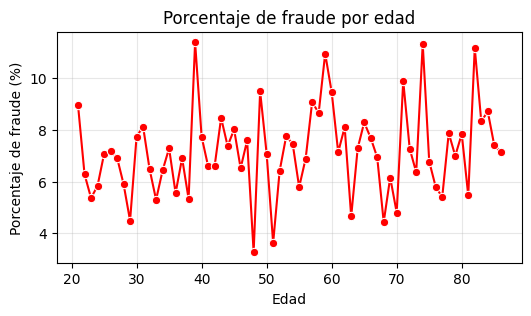

In [29]:
df_age = df.copy()
df_age['date_of_birth'] = pd.to_datetime(df_age['date_of_birth'])
df_age['birth_year'] = df_age['date_of_birth'].dt.year
df_age['age'] = pd.Timestamp('today').year - df_age['birth_year']

age_stats = df_age.groupby('age')['fraud_flag'].agg(total='count', frauds='sum').reset_index().sort_values('age')
age_stats['fraud_pct'] = age_stats['frauds'] / age_stats['total'] * 100

plt.figure(figsize=(6,3))
sns.lineplot(data=age_stats, x='age', y='fraud_pct', marker='o', color='red')
plt.title('Porcentaje de fraude por edad')
plt.xlabel('Edad')
plt.ylabel('Porcentaje de fraude (%)')
plt.grid(True, alpha=0.3)
plt.show()

Con este gráfico, llegó a la conclusión que age como feature no es relevante y tiene bastante ruido

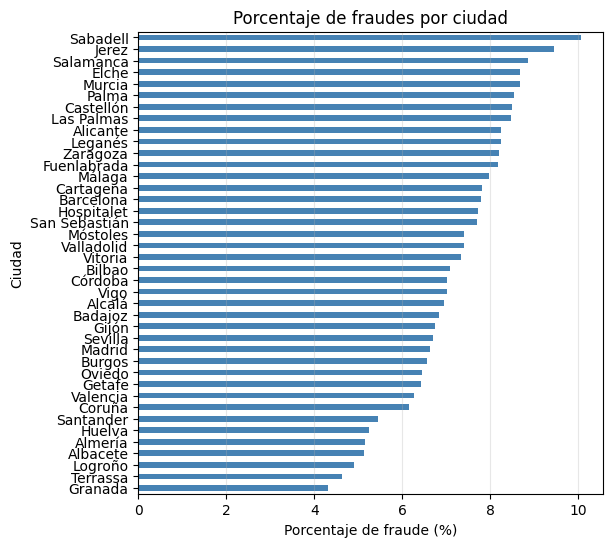

In [32]:
df_city = df.copy()

city_stats = (
    df_city.groupby('city')['fraud_flag']
    .agg(total='count', fraudes='sum')
    .reset_index()
)
city_stats['fraud_pct'] = city_stats['fraudes'] / city_stats['total'] * 100
city_stats = city_stats.sort_values('fraud_pct', ascending=True)

ax = city_stats.plot(
    kind='barh',
    x='city',
    y='fraud_pct',
    figsize=(6, 6),
    color='steelblue',
    legend=False,
)
ax.set_title('Porcentaje de fraudes por ciudad')
ax.set_xlabel('Porcentaje de fraude (%)')
ax.set_ylabel('Ciudad')
ax.grid(axis='x', alpha=0.3)
